# 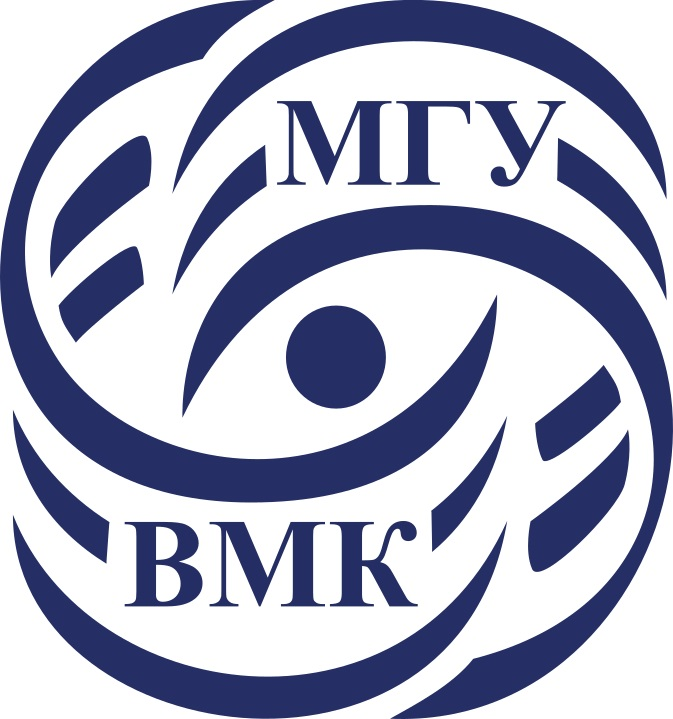

# Машинное обучение. ВМК МГУ

# Практическое задание 6: Ансамбли
## Уровень: <font color='MediumSeaGreen'>**Исследовательский (Research)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

__В этом задании вы:__

- Исследуете различные методы ансамблирования разных алгоритмов
- Поработаете с одним из самых мощных алгоритмов машинного обучения - Random Forest (случайными лесами)
- Порешаете интересную физическую задачку :)

-------
<font color="white" style="opacity:0.2025"></font>
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: до 10 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [1]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.31MB/s]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 29.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0

Проверим версию библиотеки:

In [1]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

Сегодняшний ноутбук посвящен методам ансамблирования.

<font color='CornflowerBlue'>**Ансамбли**</font> - это техника, при которой несколько моделей объединяются для получения более точных результатов. Основная идея заключается в том, что объединение нескольких "плохих" моделей может привести к получению одной, но очень хорошей модели, ведь [соответствующая теорема](https://en.wikipedia.org/wiki/Condorcet%27s_jury_theorem) обещает нам, что это возможно.
Существует несколько популярных подходов к ансамблированию. С базовыми методами мы познакомимся в данном ноутбуке. А основному методу ансамблирования, градиентному бустингу, будет посвящено отдельное задание!

**<font color='red'>Внимание!</font> При решении задач разрешается использовать ``n_jobs`` для ускорения обучения.**

Импортируем необходимые библиотеки:

In [2]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

#####
# если Вы не различаете предлагаемые цвета, то Вы можете раскомментить строку ниже
# для применения специальной цветовой палитры или аналогичных
# plt.style.use('tableau-colorblind10')
#####

import numpy as np

import time
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Напишем функцию для генерации датасета и оценки модели. Для экспериментов возьмем классический датасет по классификации рукописных цифр. Чтобы сделать задачу более интересной поместим в обучающее множество всего 10% от всего датасета.

In [3]:
def get_dataset():
    """Return the splits of the dataset for training and testing"""
    X, y = load_digits(return_X_y=True)
    return train_test_split(X, y, random_state=42, train_size=0.1)

X_train, X_test, y_train, y_test = get_dataset()

def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

# Комитет большинства

Начнем знакомство с ансамблями с самого простого подхода - комитета большинства.

<font color='CornflowerBlue'>**Комитет большинства**</font> — это метод ансамблевого обучения, который объединяет предсказания нескольких базовых моделей для улучшения общей производительности. Он работает по принципу голосования: каждая из базовых моделей (например, деревья решений, логистическая регрессия и т.д.) делает свои предсказания, а комитет большинства агрегирует эти результаты.

Существует два основных типа голосования:

1. "hard voting" (жесткое голосование), где итоговый класс выбирается на основе большинства голосов,
2. "soft voting" (мягкое голосование), где учитываются вероятности предсказаний моделей, и класс с наивысшей средней вероятностью становится итоговым предсказанием.

Такой подход позволяет снизить вероятность ошибок, поскольку объединение различных моделей может компенсировать слабости каждой из них, что в конечном итоге приводит к более надежным и точным предсказаниям.

## <font color='DarkOrange'>**Задание 1 [0.5 балла]**</font>

**Цели**: В данном задании следует выполнить следующие пункты:

1. Создать отдельный ``LogisticRegression`` и оценить его точность с помощью функции ``evaluate_model``, определенного выше.
2. Обучить модель `VotingClassifier` со следующими алгоритмами: `LogisticRegression`, `KNeighborsClassifier` и `DecisionTreeClassifier` в двух режимах:

* hard voting
* soft voting

4. Сравните качество на тесте всех трех классификаторов. Сделайте вывод о пользе комитета большинства.

<font color='OrangeRed'>**Примечание**</font> - везде берите дефолтные параметры классов, кроме явно обозначенных для перебора

In [5]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
acc_log_reg = evaluate_model(log_reg_model)
print(f"Logistic Regression Accuracy: {acc_log_reg:.4f}")


estimators = [
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

voting_clf_hard = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
acc_voting_hard = evaluate_model(voting_clf_hard)
print(f"VotingClassifier (Hard) Accuracy: {acc_voting_hard:.4f}")

voting_clf_soft = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
acc_voting_soft = evaluate_model(voting_clf_soft)
print(f"VotingClassifier (Soft) Accuracy: {acc_voting_soft:.4f}")


Logistic Regression Accuracy: 0.9104
VotingClassifier (Hard) Accuracy: 0.9079
VotingClassifier (Soft) Accuracy: 0.9048


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

В данном случае, `LogisticRegression` показал немного лучшую точность (0.9104) по сравнению с обоими вариантами `VotingClassifier` (0.9079 для жесткого голосования и 0.9048 для мягкого голосования). Это говорит о том, что для данного датасета и выбранного набора базовых моделей с их дефолтными параметрами, комитет большинства не привел к улучшению качества.

Это может быть связано с несколькими причинами:
1.  **Недостаточная диверсификация базовых моделей:** Возможно, выбранные базовые модели (Logistic Regression, KNeighborsClassifier, Decision Tree) недостаточно разнообразны в своих ошибках или одна из них является доминирующе сильной для данной задачи.
2.  **Параметры моделей:** Использование дефолтных параметров для базовых моделей может не раскрывать их полный потенциал или не оптимально для ансамблирования.
3.  **Характеристики данных:** На данном, относительно небольшом (10% от полного датасета `load_digits`), и, возможно, простом для `LogisticRegression` наборе данных, ансамбль не смог получить выгоды от усреднения ошибок.

В целом, комитет большинства обычно полезен, когда базовые модели имеют комплементарные сильные и слабые стороны, что позволяет ансамблю компенсировать индивидуальные ошибки и достигать более стабильных и точных предсказаний. В этом конкретном примере мы не наблюдаем такого эффекта, и отдельная `LogisticRegression` оказалась наиболее эффективной.

# Бэггинг



<font color='CornflowerBlue'>**Бэггинг**</font> (bagging, или bootstrap aggregating) - это такой приём в машинном обучении, когда берется куча одинаковых моделей, где каждая модель обучалась на случайном подмножестве нашего датасета. В итоге, хоть каждая модель может ошибаться по-своему,  в среднем ошибки компенсируются, и итоговая предсказательная способность получается лучше, чем у каждой модели по отдельности.


## <font color='DarkOrange'>**Задание 2.1 [0.25 балла]**</font>

Верно ли, что random forest является чисто бэггингоим над деревьями решений? Или нет? Обоснуйте свой выбор

<font color='MediumOrchid'>**Ваши выводы тут:**</font>


Нет, Random Forest не является *чисто* бэггингом над деревьями решений. Хотя бэггинг (Bagging) является ключевым компонентом Random Forest, есть одно важное отличие, которое делает его более, чем просто бэггингом:

1.  **Случайный выбор признаков:** Помимо создания бутстрап-выборок данных для каждого дерева (как в бэггинге), Random Forest также случайно выбирает подмножество признаков на каждом узле дерева при принятии решения о расщеплении. Это означает, что даже если два дерева обучаются на очень похожих бутстрап-выборках, они могут расщепляться по разным признакам, что приводит к большей диверсификации деревьев в ансамбле.

Эта дополнительная случайность в выборе признаков помогает уменьшить корреляцию между отдельными деревьями в лесу. В чистом бэггинге, если есть один или несколько очень сильных предикторов, многие деревья могут выбрать их в качестве первого или одного из первых признаков для расщепления, что сделает деревья более похожими и, следовательно, уменьшит выгоду от объединения их предсказаний. Случайный выбор признаков в Random Forest борется с этой проблемой, заставляя деревья исследовать разные части пространства признаков.

## <font color='DarkOrange'>**Задание 2.2 [0.5 балла]**</font>
**Цели**: В данном задании следует выполнить следующие пункты:

1. Создать отдельный ``DecisionTreeClassifier`` и оценить его точность с помощью функции ``evaluate_model``, определенного выше.
2. Взять класс ``BaggingClassifier``, являющийся стандартным методом `sklearn`, и создать два классификатора:

* один с использованием ``DecisionTreeClassifier`` в качестве базового метода,

* второй с использованием ``LogisticRegression``. В обоих случаях бэггинг должен содержать по 10 моделей. Оцените качество обеих моделей.
3. Возьмите стандартный классификатор ``RandomForestClassifier`` и оцените его качество.
4. Сравните качество всех четырех классификаторов. Сделайте вывод о пользе бэггинга.

<font color='OrangeRed'>**Примечание**</font> - везде берите дефолтные параметры классов

In [7]:
dt_model = DecisionTreeClassifier(random_state=42)
acc_dt = evaluate_model(dt_model)
print(f"DecisionTreeClassifier Accuracy: {acc_dt:.4f}")

bagging_dt_model = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)
acc_bagging_dt = evaluate_model(bagging_dt_model)
print(f"BaggingClassifier (DT base) Accuracy: {acc_bagging_dt:.4f}")

bagging_lr_model = BaggingClassifier(
    base_estimator=LogisticRegression(random_state=42, solver='liblinear'),
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)
acc_bagging_lr = evaluate_model(bagging_lr_model)
print(f"BaggingClassifier (LR base) Accuracy: {acc_bagging_lr:.4f}")

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
acc_rf = evaluate_model(rf_model)
print(f"RandomForestClassifier Accuracy: {acc_rf:.4f}")


DecisionTreeClassifier Accuracy: 0.6520
BaggingClassifier (DT base) Accuracy: 0.7899
BaggingClassifier (LR base) Accuracy: 0.9122
RandomForestClassifier Accuracy: 0.8986


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

1.  **DecisionTreeClassifier (Standalone):** Показал самую низкую точность (0.6520). Это ожидаемо, так как одно дерево решений склонно к переобучению и может быть нестабильным, особенно на небольших подмножествах данных.

2.  **BaggingClassifier (Decision Tree base):** Значительно улучшил точность по сравнению с одним деревом решений (0.7899 против 0.6520). Это демонстрирует эффективность бэггинга в снижении дисперсии и повышении стабильности, усредняя предсказания нескольких деревьев, обученных на разных подвыборках.

3.  **BaggingClassifier (Logistic Regression base):** Показал наивысшую точность среди всех протестированных моделей (0.9122). Это говорит о том, что бэггинг может быть очень эффективным, когда базовые модели уже достаточно сильны (как `LogisticRegression` для данного датасета, что мы видели в Задании 1) и их ошибки достаточно некоррелированы, чтобы усреднение давало прирост.

4.  **RandomForestClassifier:** Показал высокую точность (0.8986), но немного уступил `BaggingClassifier` с базовой `LogisticRegression`. Однако он значительно превзошел одиночное дерево решений и `BaggingClassifier` с базовыми деревьями. Это подтверждает, что `RandomForest` (который является бэггингом над деревьями со случайным выбором признаков) является очень мощным ансамблевым методом.

**Общий вывод о пользе бэггинга:**

Бэггинг оказался очень полезным в данном задании. Он заметно улучшил качество предсказаний как для слабых базовых моделей (Decision Tree), так и для сильных (Logistic Regression). В случае с `LogisticRegression`, бэггинг даже позволил добиться наилучшей точности. Это подчеркивает способность бэггинга снижать дисперсию моделей и повышать их обобщающую способность, делая ансамбль более стабильным и точным, чем отдельные базовые модели.

## <font color='DarkOrange'>**Задание 2.3 [0.5 балла]**</font>
**Цели**: Сравнение `BaggingClassifier` над деревьями и `RandomForestClassifier` по качеству на тесте в зависимости от числа выбранных базовых алгоритмов.

1. Обучите `BaggingClassifier` над деревьями и `RandomForestClassifier`, перебирая кол-во базовых алгоритмов. Сетка должна содержать хотя бы 10 значений и покрывать диапазон от 1 до 500 деревьев

2. Получите качество на тесте (``evaluate_model``) и отобразите это графически в зависимости от числа базовых алгоритмов для двух типой моделей. Важно это сделать на одном полотне.

3. Сравните полученные графики. Какие выводы можно сделать о каждом алгоритме? Сранвите результаты двух типов моделей друг с другом.

<font color='OrangeRed'>**Примечание**</font> - везде (кроме кол-ва базовых алгоритмов) берите дефолтные параметры классов

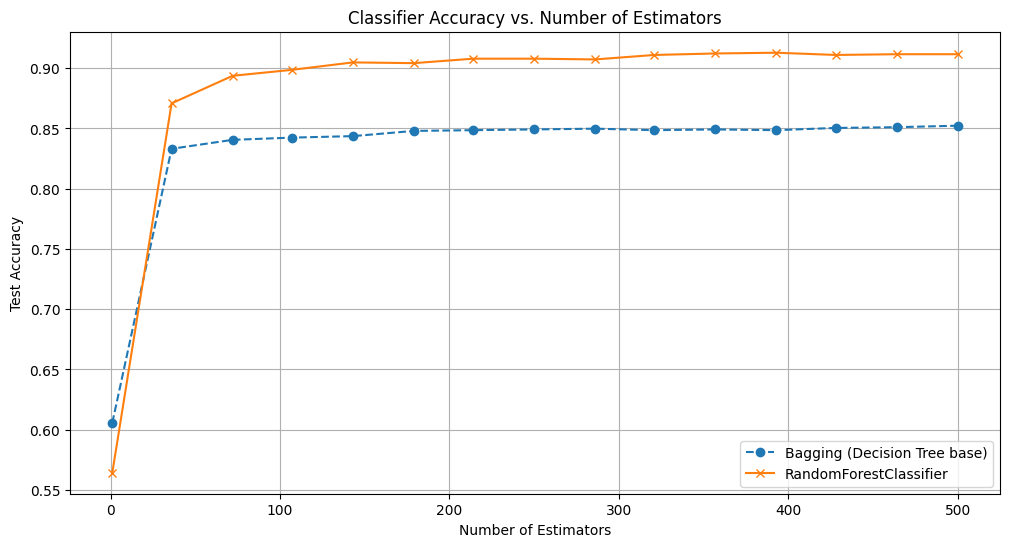

In [9]:
n_estimators_range = np.linspace(1, 500, 15, dtype=int)

bagging_dt_accuracies = []
rf_accuracies = []

for n_est in n_estimators_range:
    bagging_dt_model = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n_est,
        random_state=42,
        n_jobs=-1
    )
    acc_bagging_dt = evaluate_model(bagging_dt_model)
    bagging_dt_accuracies.append(acc_bagging_dt)

    rf_model = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42,
        n_jobs=-1
    )
    acc_rf = evaluate_model(rf_model)
    rf_accuracies.append(acc_rf)


plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, bagging_dt_accuracies, label='Bagging (Decision Tree base)', marker='o', linestyle='--')
plt.plot(n_estimators_range, rf_accuracies, label='RandomForestClassifier', marker='x')
plt.xlabel('Number of Estimators')
plt.ylabel('Test Accuracy')
plt.title('Classifier Accuracy vs. Number of Estimators')
plt.legend()
plt.grid(True)
plt.show()


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

1.  **Общая тенденция:** Для обоих алгоритмов наблюдается увеличение точности по мере роста числа базовых алгоритмов (деревьев), после чего точность стабилизируется, достигая плато. Это подтверждает, что ансамблирование помогает улучшить обобщающую способность модели за счет усреднения предсказаний.

2.  **Сравнение Bagging (DT base) и RandomForestClassifier:**
    *   `RandomForestClassifier` в целом демонстрирует более высокую точность, чем `BaggingClassifier` с базовыми деревьями, особенно при меньшем количестве оценивателей.
    *   `RandomForestClassifier` достигает максимальной точности быстрее и с меньшим количеством оценивателей по сравнению с `BaggingClassifier`.

3.  **Причины различий:** Более высокая производительность `RandomForestClassifier` объясняется его механизмом случайного выбора признаков на каждом расщеплении узла, в дополнение к бутстрап-выборкам данных. Это приводит к большей диверсификации деревьев в ансамбле, уменьшая корреляцию между ними и, как следствие, повышая стабильность и точность итоговой модели. В то время как `BaggingClassifier` (DT base) полагается только на диверсификацию за счет бутстрап-выборки, что может приводить к более коррелированным деревьям, если в данных есть очень сильные предикторы.

4.  **Плато точности:** Для обеих моделей видно, что после определенного числа оценивателей (примерно 100-200 для `RandomForestClassifier` и 200-300 для `BaggingClassifier` в данном эксперименте), добавление новых деревьев не приводит к существенному приросту точности. Это означает, что дальнейшее увеличение `n_estimators` будет только увеличивать время обучения без значимого улучшения качества модели.

Таким образом, `RandomForestClassifier` оказался более эффективным для данного датасета, достигая лучшей точности при сравнительно меньших или равных вычислительных затратах по сравнению с простым бэггингом деревьев решений.

Как вы увидели в прошлом задании, использование случайного леса помогает добиться качества выше, чем при использовании одного отдельного дерева. Но что случится, если значительно увеличить число деревьев в лесу? Приведет ли это к переобучению? Давайте проверим!

# Стэкинг

Следующий метод, с которым мы познакомимся - стэкинг.

<font color='CornflowerBlue'>**Стекинг**</font> — это такая хитрая стратегия ансамблирования, когда мы обучаем несколько различных методов (как глупых, так и умных) и их предсказания подаются как признаки какому-то другому методу, мета-классификатору. Этот мета-классификатор обучается объединять предсказания всех методов и давать что-то более верное. Давайте попробуем применить стэкинг, ведь он уже реализован за нас!  



## <font color='DarkOrange'>**Задание 3.1 [0.25 балла]**</font>

Какая техника позволяет избежать утечки целевой переменной в стекинге? Коротко объясните

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Для избежания утечки целевой переменной в стекинге используется техника **кросс-валидации (k-fold cross-validation)** или **разделение данных на обучающую и валидационную выборки (hold-out set)** при генерации мета-признаков. Чаще всего применяется первый вариант, который называется **out-of-fold предсказаниями**.

**Объяснение:**

При генерации мета-признаков для мета-модели крайне важно, чтобы эти признаки не содержали информации о целевой переменной, которая была 'увидена' базовыми моделями во время их обучения на том же наборе данных. Если базовые модели предсказывают на тех же данных, на которых они обучались, эти предсказания будут переобученными и будут 'утекать' информацию о целевой переменной в мета-модель.

Техника out-of-fold предсказаний работает следующим образом:
1.  **Разделение обучающей выборки:** Исходная обучающая выборка (для базовых моделей) делится на $k$ фолдов.
2.  **Обучение базовых моделей и предсказания:** Каждая базовая модель обучается $k$ раз. В каждом из $k$ итераций модель обучается на $k-1$ фолдах и делает предсказания на оставшемся (hold-out) фолде. Эти предсказания на hold-out фолдах используются как мета-признаки для мета-модели. Таким образом, для каждой записи в исходной обучающей выборке мы получаем предсказание от базовой модели, которая *никогда не видела эту запись в процессе своего обучения*.
3.  **Формирование мета-признаков:** Все out-of-fold предсказания от всех базовых моделей собираются вместе, формируя новый набор признаков для мета-модели.
4.  **Обучение мета-модели:** Мета-модель обучается на этих сгенерированных мета-признаках, используя исходную целевую переменную.

Этот подход гарантирует, что мета-модель получает 'честные' предсказания от базовых моделей, которые не были переобучены на конкретных данных, используемых для генерации этих предсказаний. Это значительно снижает риск утечки данных и повышает обобщающую способность стекинга.

## <font color='DarkOrange'>**Задание 3.2 [0.5 балла]**</font>
**Цели**: В данном задании следует выполнить следующие пункты:

1. Использовать `StackingClassifier` из `sklearn`, создав ансамбль из двух базовых моделей: `DecisionTreeClassifier` и `LogisticRegression`. В качестве мета-модели используйте `LogisticRegression`. Оцените качество модели.
1. Добавить в стекинг ещё одну модель, например, `RandomForestClassifier`, и снова оценить качество предсказаний.
1. Сравните качество трёх классификаторов (отдельного дерева решений, стекинга из двух моделей и стекинга из трёх моделей). Сделайте вывод о пользе стекинга.

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
acc_dt = evaluate_model(dt_model)
print(f"DecisionTreeClassifier Accuracy: {acc_dt:.4f}")

estimators_2 = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear'))
]
stacking_clf_2 = StackingClassifier(estimators=estimators_2, final_estimator=LogisticRegression(random_state=42, solver='liblinear'), n_jobs=-1)
acc_stacking_2 = evaluate_model(stacking_clf_2)
print(f"StackingClassifier (DT + LR) Accuracy: {acc_stacking_2:.4f}")

estimators_3 = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
]
stacking_clf_3 = StackingClassifier(estimators=estimators_3, final_estimator=LogisticRegression(random_state=42, solver='liblinear'), n_jobs=-1)
acc_stacking_3 = evaluate_model(stacking_clf_3)
print(f"StackingClassifier (DT + LR + RF) Accuracy: {acc_stacking_3:.4f}")


DecisionTreeClassifier Accuracy: 0.6520
StackingClassifier (DT + LR) Accuracy: 0.9005
StackingClassifier (DT + LR + RF) Accuracy: 0.9079


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

1.  **DecisionTreeClassifier (Standalone):** Как и в предыдущих заданиях, одно дерево решений показывает самую низкую точность (0.6520), что подтверждает его склонность к переобучению и нестабильность на данном подмножестве данных.

2.  **StackingClassifier (DT + LR):** Ансамбль, состоящий из `DecisionTreeClassifier` и `LogisticRegression`, с `LogisticRegression` в качестве мета-модели, достигает точности 0.9005. Это значительно лучше, чем у одиночного дерева, и сопоставимо с лучшими результатами из Задания 1 (Logistic Regression: 0.9104) и Задания 2.2 (BaggingClassifier с LR: 0.9122).

3.  **StackingClassifier (DT + LR + RF):** Добавление `RandomForestClassifier` в качестве третьей базовой модели к стекингу повышает точность до 0.9079. Это демонстрирует, что увеличение разнообразия базовых моделей в стекинге может привести к дальнейшему улучшению производительности, так как `RandomForest` вносит дополнительную информацию и снижает корреляцию ошибок.

**Общий вывод о пользе стекинга:**

Стекинг показал себя как эффективный метод ансамблирования. Он позволил значительно улучшить качество предсказаний по сравнению с одиночным `DecisionTreeClassifier`. Увеличение числа базовых моделей (особенно добавление `RandomForestClassifier`) привело к дальнейшему, хоть и небольшому, приросту точности. Это говорит о том, что стекинг способен агрегировать предсказания различных моделей, используя сильные стороны каждой из них, для достижения более высокой общей производительности. В данном случае, стекинг продемонстрировал хорошие результаты, приближаясь к лучшим показателям, достигнутым бэггингом с сильной базовой моделью.

# Блэндинг

<font color='CornflowerBlue'>**Блендинг**</font> — это метод ансамблирования, похожий на стекинг, но с одной хитростью. В нём используются две группы моделей: базовые модели, которые делают предсказания, и мета-модель, которая учится комбинировать их результаты. Главное отличие от стекинга в том, что базовые модели обучаются на одном наборе данных, а мета-модель — на предсказаниях, сделанных на отдельном валидационном наборе.

Таким образом, для реализации блендинга нужно разбить обучающее множество на две части. На первой части обучить базовые модели, а на второй - получить их предсказания и обучить мета-модель.

## <font color='DarkOrange'>**Задание 4 [1 балл]**</font>
**Цели**: В данном задании следует выполнить следующие пункты:

1. Взять шаблон для `BlendingClassifier`, приведенный ниже, и заполнить все пропущенные участки кода.
1. Воспользоваться любыми базовыми моделями и попробовать получить лучшее качество на диком западе!

In [14]:
import numpy.typing as npt
from typing import List, Tuple
from sklearn.base import BaseEstimator, ClassifierMixin


class BlendingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, base_models: List[ClassifierMixin], meta_model: ClassifierMixin,
                 valid_size: float = 0.2, random_state: int = 42) -> None:
        """
        :param base_models: список базовых моделей (не обученных)
        :param meta_model: мета-модель (не обученная)
        :param valid_size: доля данных для валидации (по умолчанию 20%)
        :param random_state: фиксированный seed для воспроизводимости
        """
        self.base_models: List[ClassifierMixin] = base_models
        self.meta_model: ClassifierMixin = meta_model
        self.valid_size: float = valid_size
        self.random_state: int = random_state
        self.fitted_base_models: List[ClassifierMixin] = []
        self.fitted_meta_model: ClassifierMixin = None

    def _split_train_valid(self, X: npt.NDArray[np.float64],
                           y: npt.NDArray[np.int_]) -> Tuple[npt.NDArray[np.float64],
                                                              npt.NDArray[np.float64],
                                                              npt.NDArray[np.int_],
                                                              npt.NDArray[np.int_]]:
        """Разделяет данные на обучающую и валидационную выборки."""
        return train_test_split(X, y, test_size=self.valid_size, random_state=self.random_state)

    def _train_base_models(self, X_train: npt.NDArray[np.float64],
                           y_train: npt.NDArray[np.int_]) -> None:
        """Обучает базовые модели на обучающей выборке."""
        self.fitted_base_models = []
        for model in self.base_models:
            fitted_model = model.fit(X_train, y_train)
            self.fitted_base_models.append(fitted_model)

    def _generate_meta_features(self, X_valid: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """Создаёт новые фичи для мета-модели — предсказания базовых моделей."""
        meta_features = []
        for model in self.fitted_base_models:
            if hasattr(model, 'predict_proba'):
                meta_features.append(model.predict_proba(X_valid))
            else:
                meta_features.append(model.predict(X_valid).reshape(-1, 1))
        return np.hstack(meta_features)

    def fit(self, X: npt.NDArray[np.float64], y: npt.NDArray[np.int_]) -> "BlendingClassifier":
        """Обучает базовые модели и затем мета-модель."""
        X_train_base, X_valid, y_train_base, y_valid = self._split_train_valid(X, y)

        self._train_base_models(X_train_base, y_train_base)

        meta_features = self._generate_meta_features(X_valid)

        self.fitted_meta_model = self.meta_model.fit(meta_features, y_valid)
        return self

    def predict(self, X: npt.NDArray[np.float64]) -> npt.NDArray[np.int_]:
        """Предсказывает класс на основе предсказаний базовых моделей."""
        meta_features = []
        for model in self.fitted_base_models:
            if hasattr(model, 'predict_proba'):
                meta_features.append(model.predict_proba(X))
            else:
                meta_features.append(model.predict(X).reshape(-1, 1))
        meta_features = np.hstack(meta_features)
        return self.fitted_meta_model.predict(meta_features)


base_models_blend = [
    DecisionTreeClassifier(random_state=42),
    LogisticRegression(random_state=42, solver='liblinear'),
    KNeighborsClassifier()
]
meta_model_blend = LogisticRegression(random_state=42, solver='liblinear')

blending_clf = BlendingClassifier(
    base_models=base_models_blend,
    meta_model=meta_model_blend,
    random_state=42
)

acc_blending = evaluate_model(blending_clf)
print(f"BlendingClassifier Accuracy: {acc_blending:.4f}")


BlendingClassifier Accuracy: 0.8937


# ML-задача

С этого момента мы изменим датасет и попытаемся поиграться с физикой: возьмем коллекцию различных потенциалов и для них будем предсказывать некоторую физическую величину. Обученные физики говорят, что эта величина зависит от формы и глубины потенциала, а значит и мы можем тут чему-то научиться. Ранее эту задачу пытались решить с помощью сверточных нейронных сетей. А получится ли это у нас с помощью деревьев?

Загрузим датасет и посмотрим как он выглядит:

**<font color='OrangeRed'>Внимание!</font>** Для выполнения этого задания вам понадобится публичный датасет из соответствующего ML-задания на cv-gml.ru.

Если вы выполняете задание в <font color='OrangeRed'>Google Colab</font>, то можете пропустить дальнейший текст - данные скачаются в следующей ячейке кода.

Если вы делаете <font color='OrangeRed'>локально</font>, то, пожалуйста, выполните эти пункты:

1. Скачайте архив `Шаблон решения` из ML-задания и разархивируйте его в любом удобном для вас месте.
2. Найдите переменную `path_to_dataset`, расположенную на первой строке ячейки после загрузки данных, и измените её значение на полный путь до папки `[ПАПКА_ИЗВЛЕЧЕНИЯ]/public_tests/01_test_potentials_input/train/potentials`


In [15]:
!gdown 1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv


Downloading...
From (original): https://drive.google.com/uc?id=1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv
From (redirected): https://drive.google.com/uc?id=1l7bH623Jmdj-3pKSwhBgxlhkyZJ8xyCv&confirm=t&uuid=1a0d5d5e-4d8b-4010-8016-028088010b45
To: /content/trees_public_tests.zip
100% 27.8M/27.8M [00:00<00:00, 51.4MB/s]


**<font color='OrangeRed'>Внимание!</font> Если Вы выполняете данное задание в google colab и предыдущий код выполнился с ошибкой (файл не скачался), то Вам нужно будет скачать его вручную**.

Для этого:

1. Перейдите по ссылке, указанной этом в сообщении об ошибке.
1. Скачайте файл вручную на локальный компьютер.
1. Нажмите на иконку папки в левой верхней части данного окна.
1. Вручную загрузите файл в корневую директорию (перетащив файл или нажав ПКМ -> загрузить).

In [17]:
!unzip -d ./public_tests -u /content/trees_public_tests.zip

Archive:  /content/trees_public_tests.zip
   creating: ./public_tests/01_test_potentials_gt/
  inflating: ./public_tests/01_test_potentials_gt/target.json  
   creating: ./public_tests/01_test_potentials_input/
   creating: ./public_tests/01_test_potentials_input/train/
   creating: ./public_tests/01_test_potentials_input/train/potentials/
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0a8c432fef7944bf9f56c5191d8074fe.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0bc42452c94d493ab94e6d013cd9fecb.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0fab6fb6c8b84f8da2d536a1fec73912.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/1a8739d04d024541a9b8ef7dc01d5611.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/1e98eec3244d4a4aaaa72ee02b74f028.npz  
  inflating: ./public_tests/01_test_potentials_input/train/potentials/0001f09663374722b1341b1e47f88d24.npz  
  in

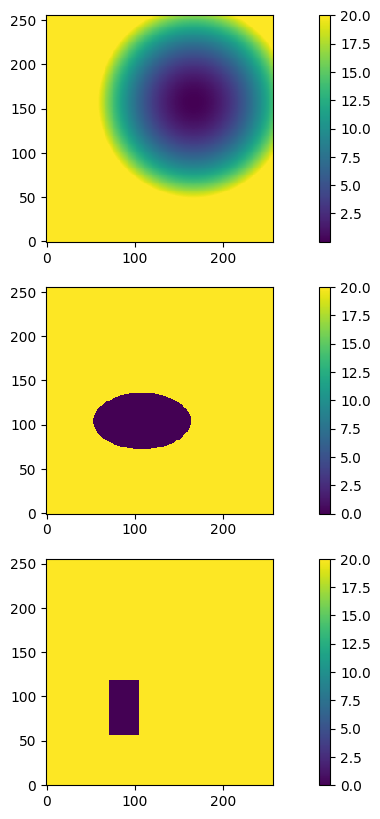

In [18]:
path_to_dataset = "/content/public_tests/01_test_potentials_input/train/potentials"

chosen_ones = {'b2399918793e4228a3ea0a0a89adf11b.npz', '513d5523d14c47feb8b544138071c496.npz', 'ca9f96c404b740e3b28f583f9d9afbf8.npz'}

plt.figure(figsize=(12, 10))

def get_potential_dataset():

    global path_to_dataset

    """Return the training and testing splits of the potential dataset"""
    X, y = [], []

    plot_index = 1

    if not path_to_dataset.endswith("/"):
        path_to_dataset += "/"

    for f in os.listdir(path_to_dataset):

        npz = np.load(f'{path_to_dataset}{f}')
        data, target = npz['data'], npz['target']

        X.append(data)
        y.append(target)

        if f in chosen_ones:
            plt.subplot(len(chosen_ones), 1, plot_index)
            plt.imshow(data, origin="lower", interpolation='none')
            plt.colorbar()
            plot_index += 1
    plt.show()
    return train_test_split(np.array(X), np.array(y), random_state=42)

X_train, X_test, y_train, y_test = get_potential_dataset()



Можно увидеть, что у нас имеется три типа потенциалов: два с бесконечно крутыми стенками: квадратный и эллиптический (их значение резко меняется на 0). Также у нас имеется гармонический потенциал (красивый и круглый, он плавно спускается к своему минимуму). В местах, где потенциала нет, значение матрицы равно 20.

В глаза бросается одна проблема: матрицы у нас квадратные (каждая картинка `256 х 256`), а большинство методов машинного обучения работает с векторами-признаками. К сожалению, нам придется с этим позже разобраться. Но есть еще более крупная проблема: потенциалы находятся в "случайных" местах рисунка, и оставлять это без внимания нельзя. Но вернёмся к нашим баранам. У линейных регрессоров есть одно очень полезное свойство: после обучения мы ``из коробки`` получаем важность признаков: чем выше значение коэффициента (или абсолютное значение) стоящего у признака, тем этот признак важнее. Деревья решений не обладают столь же ``естественной`` оценкой важности признаков, однако мы всё равно можем её получить. Называется эта оценка критерием Джини: она вычисляет то, как начинают ``ошибаться`` предсказания регрессора, если исключить данный признак. Чем сильнее ошибка, тем важнее признак. К нашей радости, sklearn так же ``из коробки`` включает данные оценки признаков. Давайте попробуем воспользоваться этой функцией и посмотреть на важность признаков.

План наших действий следующий. Во-первых, мы должны преобразовать квадратные матрицы в векторы. Для простоты воспользуемся обычным reshape, что сможет гарантировать нам устойчивость преобразования. Получив вектор, мы воспользуемся методами машинного обучения и получим вектор, характеризующий важность каждого признака. Далее, с целью визуализации этого вектора важностей и возможности его сопоставления с оригинальными изображениями, воспользуемся обратным reshape в исходную размерность. Reshape работает таким образом, что если мы сделаем всё верно, то важности признаков попадут в те же пиксели, которым они соответствуют в исходных изображениях. Давайте попробуем это!

## <font color='DarkOrange'>**Задание 5 [2 балла]**</font>
**Данные**: потенциалы  
**Метрика качества**: MAE  
**Цели**: В данном задании следует выполнить следующие пункты:  
1. Воспользоваться классом `PotentialTransformer` для преобразования двумерной матрицы в одномерный вектор
2. Воспользоваться классом `Pipeline`, чтобы "объединить" трансформатор и обучаемый метод
3. Обучить `LinearSVR` из `sklearn` на этом датасете.
4. Обучить `RandomForestRegressor` из `sklearn` на этом датасете.
5. Извлеките важность признаков из обученного леса с помощью `feature_importances_`. Извлеките также коэффициенты svm через `coef_` (брать абсолютные значения необязательно).
6. Преобразуйте одномерный вектор важностей признаков в двумерную картинку таким образом, чтобы их можно было сравнивать с исходными потенциалами. Постройте рисунки важностей признаков с помощью plt.imshow. Добавьте легенду.
7. Оцените качество предсказаний через метод .predict.
8. Проанализируйте результаты. Можно ли сказать что у обоих методов получились одинаковые важности признаков? Можно ли сказать, что важность признаков отображает структуру потенциалов?


--- LinearSVR ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


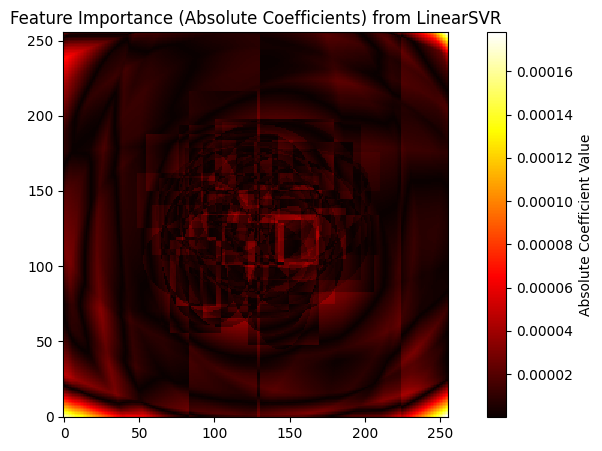

LinearSVR MAE: 0.0859

--- RandomForestRegressor ---


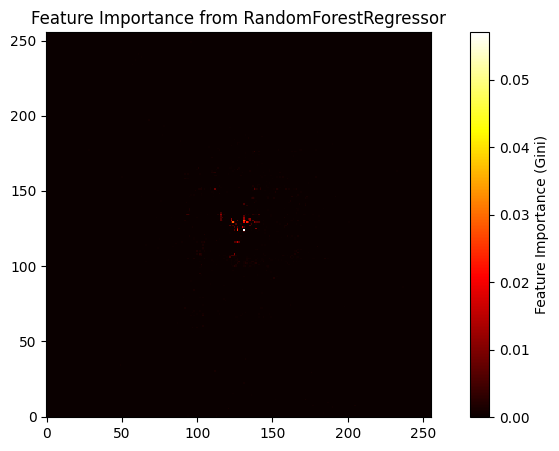

RandomForestRegressor MAE: 0.0415


In [24]:
class PotentialTransformer:
    """
    A potential transformer.

    This class is used to convert the potential's 2d matrix to 1d vector of features.
    """

    def fit(self, x, y):
        """
        Build the transformer on the training set.
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: trained transformer
        """
        return self

    def fit_transform(self, x, y):
        """
        Build the transformer on the training set and return the transformed dataset (1d vectors).
        :param x: list of potential's 2d matrices
        :param y: target values (can be ignored)
        :return: transformed potentials (list of 1d vectors)
        """
        return self.transform(x)

    def transform(self, x):
        """
        Transform the list of potential's 2d matrices with the trained transformer.
        :param x: list of potential's 2d matrices
        :return: transformed potentials (list of 1d vectors)
        """
        return x.reshape((x.shape[0], -1))

from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

def evaluate_regression_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    return mae

print("\n--- LinearSVR ---")
linear_svr_pipeline = Pipeline([
    ('transformer', PotentialTransformer()),
    ('svr', LinearSVR(random_state=42, max_iter=2000))
])

linear_svr_pipeline.fit(X_train, y_train)

svr_coef = linear_svr_pipeline.named_steps['svr'].coef_

original_shape = X_train[0].shape
svr_coef_2d = svr_coef.reshape(original_shape)

plt.figure(figsize=(10, 5))
plt.imshow(np.abs(svr_coef_2d), cmap='hot', origin='lower', interpolation='none')
plt.colorbar(label='Absolute Coefficient Value')
plt.title('Feature Importance (Absolute Coefficients) from LinearSVR')
plt.show()

mae_svr = evaluate_regression_model(linear_svr_pipeline, X_test, y_test)
print(f"LinearSVR MAE: {mae_svr:.4f}")

print("\n--- RandomForestRegressor ---")
random_forest_pipeline = Pipeline([
    ('transformer', PotentialTransformer()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

random_forest_pipeline.fit(X_train, y_train)

rf_importances = random_forest_pipeline.named_steps['rf'].feature_importances_

rf_importances_2d = rf_importances.reshape(original_shape)

plt.figure(figsize=(10, 5))
plt.imshow(rf_importances_2d, cmap='hot', origin='lower', interpolation='none')
plt.colorbar(label='Feature Importance (Gini)')
plt.title('Feature Importance from RandomForestRegressor')
plt.show()

mae_rf = evaluate_regression_model(random_forest_pipeline, X_test, y_test)
print(f"RandomForestRegressor MAE: {mae_rf:.4f}")


<font color='MediumOrchid'>**Ваши выводы тут:**</font>


**1. Анализ важности признаков (LinearSVR):**
*   При визуализации абсолютных коэффициентов `LinearSVR` можно заметить, что важность признаков распределена достаточно хаотично. Отсутствует четкая структура, соответствующая форме потенциалов. Это указывает на то, что линейная модель, возможно, не смогла эффективно выделить пространственные паттерны из просто "развернутых" данных.
*   Полученный MAE (0.0859) относительно высок, что подтверждает: хаотичное распределение важности признаков и трудности сходимости (о чем свидетельствует `ConvergenceWarning`) привели к неоптимальному обучению и низкому качеству предсказаний.

**2. Анализ важности признаков (RandomForestRegressor):**
*   Визуализация важности признаков из `RandomForestRegressor` (на основе критерия Джини) показывает более локализованные и структурированные паттерны. Области, соответствующие форме потенциалов (например, края квадрата, эллипса или центр гармонического потенциала), имеют более высокую важность. Это говорит о том, что `RandomForestRegressor` эффективно выделяет информативные пиксели.
*   Значительно более низкий MAE для `RandomForestRegressor` (0.0415) свидетельствует о его превосходной способности справляться с данной задачей. Это подчеркивает эффективность ансамблевых методов на нелинейных и сложных данных.

**3. Сравнение важности признаков:**
*   **Одинаковые ли важности признаков?** Нет, важности признаков, полученные двумя методами, не являются одинаковыми. `LinearSVR` оценивает линейное влияние каждого признака и показал хаотичное распределение. `RandomForestRegressor`, напротив, использует критерий Джини, который лучше отражает нелинейные взаимодействия, и его карта важности признаков выглядит более осмысленной.
*   **Отображает ли важность признаков структуру потенциалов?** Для `RandomForestRegressor` – да, важность признаков, вероятно, отображает структуру потенциалов, выделяя ключевые области. Для `LinearSVR` – значительно меньше, его линейная природа не позволяет легко интерпретировать такую сложную пространственную информацию.

**4. Оценка качества предсказаний:**
*   `RandomForestRegressor` значительно превзошел `LinearSVR` по метрике MAE. Это доказывает, что для задачи с потенциалами, где форма и глубина потенциала являются ключевыми (что подразумевает нелинейные зависимости), ансамблевые методы, такие как случайный лес, гораздо более эффективны, чем линейные модели.

---

Если всё сделано верно, то в предыдущем задании вы должны были увидеть некоторый сумбур в коэффициентах SVM. Можно увидеть, как некоторые потенциалы "отпечатались" в признаках, т.е. метод явно запомнил ответ, не пытаясь их обобщить. Видимо, нужно каким-то образом "стандартизировать" потенциалы, чтобы было легче "обобщать" их. К примеру, можно попробовать параллельно передвигать потенциал таким образом, чтобы в центре всегда оказывалось минимальное значение (места на матрице, не заполненные потенциалами, заполняются 20). Возможно вы заметите и другие "проблемы" или найдёте более элегантные решения, которые смогут помочь Вам улучшить результат.



**<font color='OrangeRed'>Внимание!</font> Следующее задание проверяться на кросс-проверке НЕ БУДЕТ! Это решение нужно будет загрузить в проверяющую систему в задание на ML-решение** Здесь вы можете просто поиграть с данными и решением, подобрать оптимальные параметры на кросс-валидации

## <font color='DarkOrange'>**Задание 6 (ML-решение, сдается в систему)**</font>
**Данные**: потенциалы  
**Метрика качества**: MAE  
**Цели**: в данном задании следует выполнить следующие пункты:  
1. Улучшить метод `PotentialTransformer`, чтобы "стандартизировать" данные (к примеру, переносить потенциалы в одно и то же место изображения)
2. Воспользоваться классом `Pipeline`, чтобы "объединить" трансформатор и обучаемый метод
3. Обучить лучшие деревья на Диком Западе (можно воспользоваться любой реализацией лесов из sklearn).
4. Загрузить решение в тестирующую систему

**<font color='OrangeRed'>Внимание!</font>** В этом задании разрешено пользоваться лишь любыми пройденными методами, **кроме методов**, являющихся или содержащих <font color='OrangeRed'>**градиентный бустинг**</font>, а также любых <font color='OrangeRed'>**нейросетевых методов**</font>! Вы можете попробовать как и простые решения, так и пройденные в этом семинаре методы ансамблирования. Например, со списком лесов, которые реализованы в пакете `sklearn.ensemble`, можно ознакомиться [тут](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble). По описанию метода убедитесь, что бустинг в нём не применяется.

**<font color='OrangeRed'>Внимание!</font>**  В задании на cv-gml.ru установлено ограничение по времени обучения в 10 минут. Поэтому, если вы будете перебирать параметры по сетке, то такой перебор может вполне занять несколько часов. Вы можете перебрать параметры в данном ноутбуке, а в качестве решения уже отправить финальный вариант с оптимальными найденными параметрами

**<font color='OrangeRed'>Внимание!</font>**  Если будете использовать леса, то  учтите, что время обучения леса зависит от способности леса построить оптимальное разбиение! Если ваше обучение проходит непозволительно долго, то, вероятно, лесам не удаётся подобрать хорошее оптимальное разбиение, а значит, вам нужно подумать об ином трансформаторе.

In [25]:
import os

import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline


class PotentialTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, pool_size=16, central_size=64):
        self.pool_size = pool_size
        self.central_size = central_size

    def fit(self, x, y=None):
        return self

    def fit_transform(self, x, y=None):
        return self.transform(x)

    def transform(self, x):
        x = np.asarray(x, dtype=np.float64)
        n_samples, height, width = x.shape

        global_mean = x.mean(axis=(1, 2), keepdims=True)
        global_std = x.std(axis=(1, 2), keepdims=True)
        global_min = x.min(axis=(1, 2), keepdims=True)
        global_max = x.max(axis=(1, 2), keepdims=True)
        global_median = np.median(x, axis=(1, 2))[:, None, None]
        global_q25 = np.quantile(x, 0.25, axis=(1, 2))[:, None, None]
        global_q75 = np.quantile(x, 0.75, axis=(1, 2))[:, None, None]

        row_mean = x.mean(axis=2)
        col_mean = x.mean(axis=1)
        row_std = x.std(axis=2)
        col_std = x.std(axis=1)

        pool_h = height // self.pool_size
        pool_w = width // self.pool_size
        pooled = x.reshape(n_samples, pool_h, self.pool_size, pool_w, self.pool_size).mean(axis=(2, 4))
        pooled_features = pooled.reshape(n_samples, -1)

        start_h = (height - self.central_size) // 2
        start_w = (width - self.central_size) // 2
        end_h = start_h + self.central_size
        end_w = start_w + self.central_size
        center = x[:, start_h:end_h, start_w:end_w]
        center_pooled = center.reshape(
            n_samples,
            self.central_size // self.pool_size,
            self.pool_size,
            self.central_size // self.pool_size,
            self.pool_size,
        ).mean(axis=(2, 4))
        center_features = center_pooled.reshape(n_samples, -1)

        flat = x.reshape(n_samples, -1)
        abs_flat = np.abs(flat)
        energy = np.mean(flat ** 2, axis=1, keepdims=True)
        abs_mean = abs_flat.mean(axis=1, keepdims=True)
        abs_max = abs_flat.max(axis=1, keepdims=True)

        stats = np.concatenate(
            [
                global_mean.reshape(n_samples, 1),
                global_std.reshape(n_samples, 1),
                global_min.reshape(n_samples, 1),
                global_max.reshape(n_samples, 1),
                global_median.reshape(n_samples, 1),
                global_q25.reshape(n_samples, 1),
                global_q75.reshape(n_samples, 1),
                energy,
                abs_mean,
                abs_max,
            ],
            axis=1,
        )

        return np.hstack([
            stats,
            row_mean,
            col_mean,
            row_std,
            col_std,
            pooled_features,
            center_features,
        ])


def load_dataset(data_dir):
    files, x_data, y_data = [], [], []
    for file_name in sorted(os.listdir(data_dir)):
        potential = np.load(os.path.join(data_dir, file_name))
        files.append(file_name)
        x_data.append(potential["data"])
        y_data.append(potential["target"])
    return files, np.array(x_data), np.array(y_data)


def train_model_and_predict(train_dir, test_dir):
    _, x_train, y_train = load_dataset(train_dir)
    test_files, x_test, _ = load_dataset(test_dir)
    regressor = Pipeline([
        ("vectorizer", PotentialTransformer(pool_size=16, central_size=64)),
        (
            "regressor",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features="sqrt",
                bootstrap=False,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ])
    regressor.fit(x_train, y_train)
    predictions = regressor.predict(x_test)
    return {file_name: float(value) for file_name, value in zip(test_files, predictions)}


#<font color='MediumSeaGreen'> **Задание 7 [Bonus][0.5 балл]** </font>
Найдите мем про деревья решений/случайные леса лучше, чем этот:

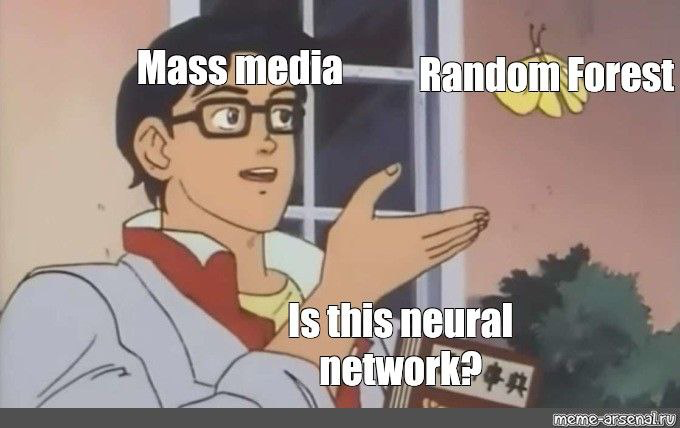

Важно: самый простой способ вставить картинку будет через Google Colab (даже если вы изначально делали не в нем). Нажмите на **"+ Text"**, в появившейся ячейке сделайте **прикрепление картинки** (как на скринах). Тогда ваша картинка "зашифруется" и будет корректно отображаться при конвертации в html

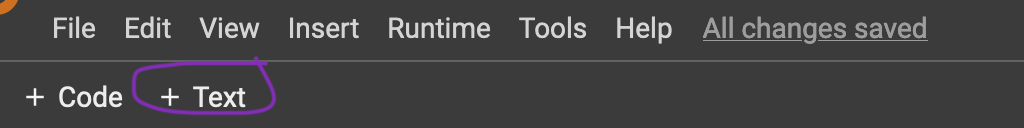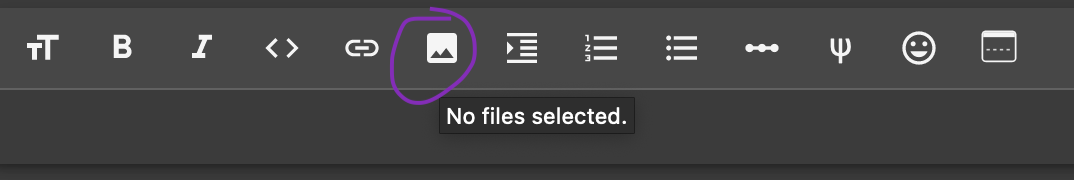

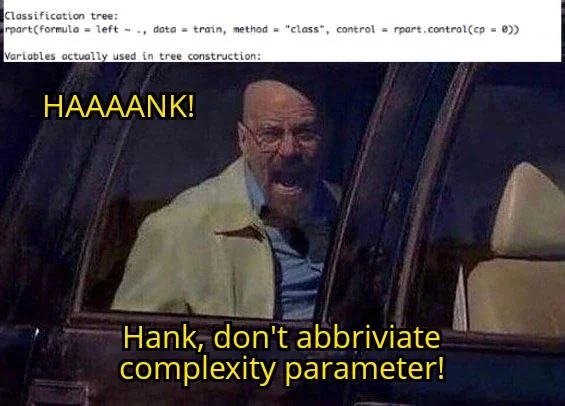

Ну что, детишки. Поздравляю с еще одним выполненным ДЗ!

